# Surgical Instrument Segmentation and Tracking

This notebook is designed for **Google Colab with a T4 GPU**.

It performs one direct workflow:

1. Mount Google Drive and load the EndoVis dataset.
2. Build sequence-safe train, validation, and test lists in memory.
3. Fine-tune two fully pretrained segmentation models: DeepLabV3-MobileNetV3 and SegFormer-B0.
4. Compare their segmentation accuracy and speed.
5. Use the best validation model for predictions and a CholecT50 tracking demo.

No split files or copied train/validation folders are created. The notebook reads EndoVis directly from Google Drive and creates the sequence-safe split lists only in memory.

## 1. Colab setup

Before running, select **Runtime > Change runtime type > T4 GPU**.

In [1]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "transformers>=4.45", "accelerate>=1.0"
])

0

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from __future__ import annotations

import gc
import json
import math
import random
import re
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFilter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms as T
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF

# Only normal training hyperparameters are kept here.
PROJECT_ROOT = Path("/content/drive/MyDrive/CV Project")
IMAGE_SIZE = (512, 512)
BATCH_SIZE = 8
EPOCHS = 10
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 3
NUM_WORKERS = 4
SEED = 42

DRIVE_DATASET = PROJECT_ROOT / "Surgical Instruments Dataset" / "endovis2018"
ENDOVIS_ROOT = DRIVE_DATASET
CHOLECT_ROOT = PROJECT_ROOT / "Surgical Instruments Dataset" / "cholect50-challenge-val"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
RESULT_DIR = PROJECT_ROOT / "results"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

assert torch.cuda.is_available(), "Select a T4 GPU from Colab Runtime settings."
DEVICE = torch.device("cuda")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

print("GPU:", torch.cuda.get_device_name(0))
print("Project:", PROJECT_ROOT)

GPU: Tesla T4
Project: /content/drive/MyDrive/CV Project


## 2. Load EndoVis and split by complete sequence

The physical `train` and `val` folders contain different portions of the same surgical sequences. The code combines their file paths in memory and uses:

- Sequences 1-8 for training: 2,400 pairs
- Sequence 9 for validation: 300 pairs
- Sequence 10 for final testing: 300 pairs

This prevents nearby frames from the same surgery appearing in both training and validation. Images and masks are read directly from Google Drive.

In [4]:
assert ENDOVIS_ROOT.is_dir(), f"EndoVis dataset not found: {ENDOVIS_ROOT}"

FRAME_PATTERN = re.compile(r"seq_(\d+)_frame(\d+)\.bmp$")


def collect_pairs(root: Path):
    images = {path.name: path for path in root.glob("*/image/*.bmp")}
    masks = {path.name: path for path in root.glob("*/label/*.bmp")}
    assert images.keys() == masks.keys(), "Every EndoVis image must have a same-named mask."

    train_samples, val_samples, test_samples = [], [], []
    for filename in sorted(images):
        match = FRAME_PATTERN.fullmatch(filename)
        assert match is not None, f"Unexpected filename: {filename}"
        sequence, frame = map(int, match.groups())
        sample = (images[filename], masks[filename], sequence, frame)
        if sequence <= 8:
            train_samples.append(sample)
        elif sequence == 9:
            val_samples.append(sample)
        elif sequence == 10:
            test_samples.append(sample)

    return train_samples, val_samples, test_samples


train_samples, val_samples, test_samples = collect_pairs(ENDOVIS_ROOT)
print("Train:", len(train_samples), "Validation:", len(val_samples), "Test:", len(test_samples))
assert (len(train_samples), len(val_samples), len(test_samples)) == (2400, 300, 300)

Train: 2400 Validation: 300 Test: 300


Class IDs in this mask: [0 1 2 7]


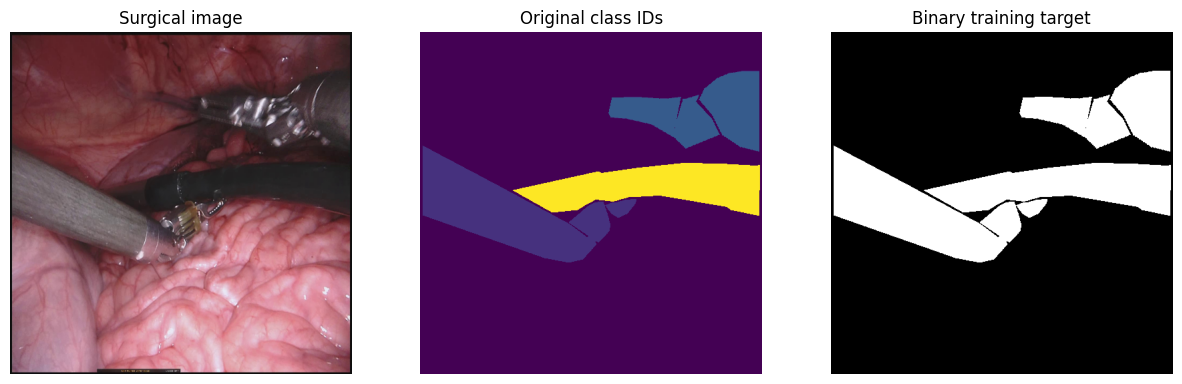

In [5]:
# Show that mask pixels store class IDs 0-7 even though the masks look black in an image viewer.
image_path, mask_path, sequence, frame = train_samples[0]
image = np.asarray(Image.open(image_path).convert("RGB"))
class_mask = np.asarray(Image.open(mask_path), dtype=np.uint8)
binary_mask = class_mask > 0

print("Class IDs in this mask:", np.unique(class_mask))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image)
axes[0].set_title("Surgical image")
axes[1].imshow(class_mask, cmap="viridis", vmin=0, vmax=7)
axes[1].set_title("Original class IDs")
axes[2].imshow(binary_mask, cmap="gray")
axes[2].set_title("Binary training target")
for axis in axes:
    axis.axis("off")
plt.show()

## 3. Dataset and augmentation

The original masks remain unchanged. The dataset converts every class ID above zero into the binary instrument class during loading.

- Crop, rotation, and flip are applied identically to image and mask.
- Color and blur augmentation are applied only to the RGB image.
- Masks always use nearest-neighbor interpolation.

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class PairedTransform:
    def __init__(self, training: bool):
        self.training = training
        self.color = T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.20, hue=0.03)

    def __call__(self, image: Image.Image, mask: Image.Image):
        if self.training:
            crop = T.RandomResizedCrop.get_params(image, scale=(0.80, 1.0), ratio=(0.90, 1.10))
            image = TF.resized_crop(image, *crop, IMAGE_SIZE, InterpolationMode.BILINEAR, antialias=True)
            mask = TF.resized_crop(mask, *crop, IMAGE_SIZE, InterpolationMode.NEAREST)

            if random.random() < 0.5:
                image, mask = TF.hflip(image), TF.hflip(mask)

            angle = random.uniform(-10, 10)
            image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR, fill=0)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST, fill=0)

            image = self.color(image)
            if random.random() < 0.15:
                image = image.filter(ImageFilter.GaussianBlur(random.uniform(0.3, 1.2)))
        else:
            image = TF.resize(image, IMAGE_SIZE, InterpolationMode.BILINEAR, antialias=True)
            mask = TF.resize(mask, IMAGE_SIZE, InterpolationMode.NEAREST)

        image = TF.normalize(TF.to_tensor(image), IMAGENET_MEAN, IMAGENET_STD)
        mask = torch.from_numpy(np.array(mask, dtype=np.uint8, copy=True))
        mask = (mask > 0).float().unsqueeze(0)
        return image, mask


class EndoVisDataset(Dataset):
    def __init__(self, samples, training: bool):
        self.samples = samples
        self.transform = PairedTransform(training)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, mask_path, sequence, frame = self.samples[index]
        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        image, mask = self.transform(image, mask)
        return image, mask


train_loader = DataLoader(
    EndoVisDataset(train_samples, training=True),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
    drop_last=True,
)
val_loader = DataLoader(
    EndoVisDataset(val_samples, training=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
)
test_loader = DataLoader(
    EndoVisDataset(test_samples, training=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
)

batch_images, batch_masks = next(iter(train_loader))
print("Images:", batch_images.shape, "Masks:", batch_masks.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Images: torch.Size([8, 3, 512, 512]) Masks: torch.Size([8, 1, 512, 512])


## 4. The two pretrained models

Both models start from complete pretrained semantic-segmentation checkpoints rather than only a pretrained encoder:

1. **DeepLabV3-MobileNetV3:** starts from TorchVision's COCO/VOC pretrained segmentation weights. It is the simpler deployment-oriented baseline.
2. **SegFormer-B0:** starts from the official ADE20K pretrained segmentation checkpoint. It is the accuracy-oriented comparison.

Their original multiclass output layers are replaced with one binary instrument-segmentation output. The rest of each pretrained network is fine-tuned on EndoVis.

In [7]:
class DeepLabBinary(nn.Module):
    def __init__(self):
        super().__init__()
        from torchvision.models.segmentation import (
            DeepLabV3_MobileNet_V3_Large_Weights,
            deeplabv3_mobilenet_v3_large,
        )
        self.model = deeplabv3_mobilenet_v3_large(
            weights=DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT
        )
        self.model.classifier[-1] = nn.Conv2d(256, 1, 1)
        self.model.aux_classifier = None

    def forward(self, x):
        return self.model(x)["out"]


class SegFormerBinary(nn.Module):
    def __init__(self):
        super().__init__()
        from transformers import SegformerForSemanticSegmentation
        self.model = SegformerForSemanticSegmentation.from_pretrained(
            "nvidia/segformer-b0-finetuned-ade-512-512",
            num_labels=1,
            ignore_mismatched_sizes=True,
        )

    def forward(self, x):
        logits = self.model(pixel_values=x).logits
        return F.interpolate(logits, size=x.shape[-2:], mode="bilinear", align_corners=False)


MODEL_BUILDERS = {
    "DeepLabV3-MobileNetV3": DeepLabBinary,
    "SegFormer-B0": SegFormerBinary,
}

## 5. Loss, metrics, and training

Training uses mixed-precision FP16, pinned-memory loading, channels-last tensors, and cuDNN benchmarking for the T4. The best validation-IoU checkpoint is saved for every model. Early stopping prevents unnecessary epochs after validation quality stops improving.

In [8]:
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        probabilities = torch.sigmoid(logits)
        intersection = (probabilities * targets).sum((1, 2, 3))
        denominator = probabilities.sum((1, 2, 3)) + targets.sum((1, 2, 3))
        dice_loss = 1 - ((2 * intersection + self.smooth) / (denominator + self.smooth)).mean()
        return bce + dice_loss


class Metrics:
    def __init__(self):
        self.tp = self.fp = self.fn = self.tn = 0

    def update(self, logits, targets):
        predictions = torch.sigmoid(logits) >= 0.5
        targets = targets >= 0.5
        self.tp += int((predictions & targets).sum())
        self.fp += int((predictions & ~targets).sum())
        self.fn += int((~predictions & targets).sum())
        self.tn += int((~predictions & ~targets).sum())

    def result(self):
        eps = 1e-8
        return {
            "dice": 2 * self.tp / (2 * self.tp + self.fp + self.fn + eps),
            "iou": self.tp / (self.tp + self.fp + self.fn + eps),
            "precision": self.tp / (self.tp + self.fp + eps),
            "recall": self.tp / (self.tp + self.fn + eps),
        }


def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    training = optimizer is not None
    model.train(training)
    metrics = Metrics()
    total_loss = 0.0
    total_images = 0

    for images, masks in loader:
        images = images.to(DEVICE, non_blocking=True).contiguous(memory_format=torch.channels_last)
        masks = masks.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = model(images)
                loss = criterion(logits, masks)

            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * images.size(0)
        total_images += images.size(0)
        metrics.update(logits.detach(), masks)

    return {"loss": total_loss / total_images, **metrics.result()}


def train_model(name, builder):
    print(f"\n{'=' * 70}\nTraining {name}\n{'=' * 70}")
    model = builder().to(DEVICE, memory_format=torch.channels_last)
    criterion = BCEDiceLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    scaler = torch.amp.GradScaler("cuda")

    checkpoint_path = CHECKPOINT_DIR / f"{name.lower().replace(' ', '_')}_best.pth"
    best_iou = -1.0
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, EPOCHS + 1):
        train_metrics = run_epoch(model, train_loader, criterion, optimizer, scaler)
        with torch.inference_mode():
            val_metrics = run_epoch(model, val_loader, criterion)
        scheduler.step()

        history.append({"epoch": epoch, "train": train_metrics, "validation": val_metrics})
        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"train loss {train_metrics['loss']:.4f}, IoU {train_metrics['iou']:.4f} | "
            f"val loss {val_metrics['loss']:.4f}, IoU {val_metrics['iou']:.4f}, "
            f"Dice {val_metrics['dice']:.4f}"
        )

        if val_metrics["iou"] > best_iou:
            best_iou = val_metrics["iou"]
            epochs_without_improvement = 0
            torch.save({
                "model": model.state_dict(),
                "model_name": name,
                "epoch": epoch,
                "validation": val_metrics,
            }, checkpoint_path)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                print("Early stopping: validation IoU stopped improving.")
                break

    del model, optimizer, scaler
    gc.collect()
    torch.cuda.empty_cache()
    return checkpoint_path, history, best_iou

## 6. Fine-tune DeepLabV3-MobileNetV3

This cell trains only DeepLabV3-MobileNetV3 and stores its best validation-IoU checkpoint.

In [9]:
training_results = {}

deeplab_name = "DeepLabV3-MobileNetV3"
deeplab_checkpoint, deeplab_history, deeplab_best_iou = train_model(
    deeplab_name, MODEL_BUILDERS[deeplab_name]
)
training_results[deeplab_name] = {
    "checkpoint": deeplab_checkpoint,
    "history": deeplab_history,
    "best_validation_iou": deeplab_best_iou,
}
print(f"DeepLab best validation IoU: {deeplab_best_iou:.4f}")


Training DeepLabV3-MobileNetV3
Downloading: "https://download.pytorch.org/models/deeplabv3_mobilenet_v3_large-fc3c493d.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_mobilenet_v3_large-fc3c493d.pth


100%|██████████| 42.3M/42.3M [00:00<00:00, 144MB/s]


Epoch 01/10 | train loss 0.3249, IoU 0.7966 | val loss 0.1803, IoU 0.8495, Dice 0.9186
Epoch 02/10 | train loss 0.1636, IoU 0.8805 | val loss 0.1720, IoU 0.8424, Dice 0.9144
Epoch 03/10 | train loss 0.1372, IoU 0.8961 | val loss 0.1414, IoU 0.8674, Dice 0.9290
Epoch 04/10 | train loss 0.1294, IoU 0.9001 | val loss 0.1485, IoU 0.8624, Dice 0.9261
Epoch 05/10 | train loss 0.1184, IoU 0.9073 | val loss 0.1503, IoU 0.8562, Dice 0.9225
Epoch 06/10 | train loss 0.1115, IoU 0.9114 | val loss 0.1540, IoU 0.8606, Dice 0.9251
Early stopping: validation IoU stopped improving.
DeepLab best validation IoU: 0.8674


## 7. Fine-tune SegFormer-B0

This cell trains only SegFormer-B0. Run it after the DeepLab cell so both results are available for comparison.

In [10]:
segformer_name = "SegFormer-B0"
segformer_checkpoint, segformer_history, segformer_best_iou = train_model(
    segformer_name, MODEL_BUILDERS[segformer_name]
)
training_results[segformer_name] = {
    "checkpoint": segformer_checkpoint,
    "history": segformer_history,
    "best_validation_iou": segformer_best_iou,
}
print(f"SegFormer best validation IoU: {segformer_best_iou:.4f}")

print("\nBest validation IoU:")
for model_name, result in training_results.items():
    print(f"{model_name:28s}: {result['best_validation_iou']:.4f}")


Training SegFormer-B0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `150`.


model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([1])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([1, 256, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch 01/10 | train loss 0.4194, IoU 0.8012 | val loss 0.1801, IoU 0.8681, Dice 0.9294
Epoch 02/10 | train loss 0.1638, IoU 0.8894 | val loss 0.1426, IoU 0.8699, Dice 0.9304
Epoch 03/10 | train loss 0.1405, IoU 0.8974 | val loss 0.1170, IoU 0.8870, Dice 0.9401
Epoch 04/10 | train loss 0.1245, IoU 0.9067 | val loss 0.1441, IoU 0.8572, Dice 0.9231
Epoch 05/10 | train loss 0.1226, IoU 0.9065 | val loss 0.1031, IoU 0.9006, Dice 0.9477
Epoch 06/10 | train loss 0.1135, IoU 0.9135 | val loss 0.1056, IoU 0.8948, Dice 0.9445
Epoch 07/10 | train loss 0.1093, IoU 0.9156 | val loss 0.0990, IoU 0.9015, Dice 0.9482
Epoch 08/10 | train loss 0.0951, IoU 0.9220 | val loss 0.0912, IoU 0.9099, Dice 0.9528
Epoch 09/10 | train loss 0.0909, IoU 0.9238 | val loss 0.0902, IoU 0.9119, Dice 0.9539
Epoch 10/10 | train loss 0.0901, IoU 0.9241 | val loss 0.0908, IoU 0.9097, Dice 0.9527
SegFormer best validation IoU: 0.9119

Best validation IoU:
DeepLabV3-MobileNetV3       : 0.8674
SegFormer-B0                : 0.9

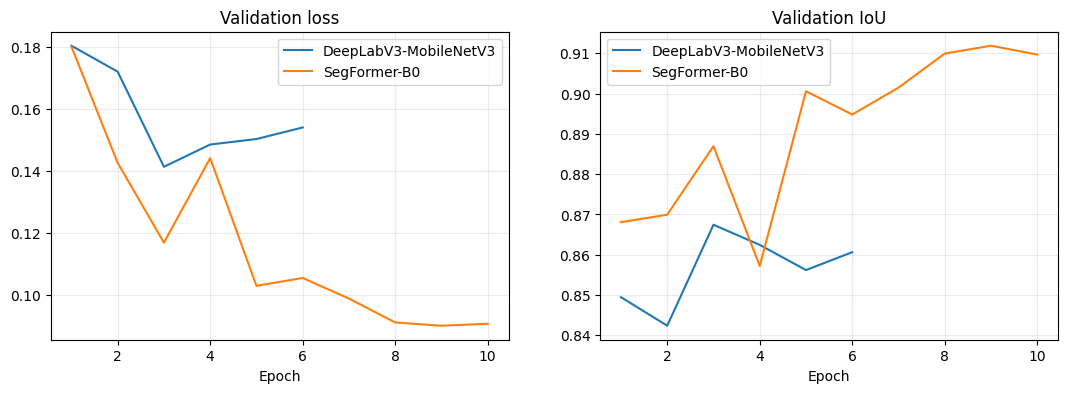

In [11]:
# Plot the validation curves produced above.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for model_name, result in training_results.items():
    epochs = [row["epoch"] for row in result["history"]]
    val_loss = [row["validation"]["loss"] for row in result["history"]]
    val_iou = [row["validation"]["iou"] for row in result["history"]]
    axes[0].plot(epochs, val_loss, label=model_name)
    axes[1].plot(epochs, val_iou, label=model_name)

axes[0].set_title("Validation loss")
axes[1].set_title("Validation IoU")
for axis in axes:
    axis.set_xlabel("Epoch")
    axis.legend()
    axis.grid(alpha=0.25)
plt.show()

## 8. Final test comparison and T4 speed

Sequence 10 is used only here. The final deployment model is selected by validation IoU, not by repeatedly choosing from test results.

In [12]:
def load_trained_model(name):
    model = MODEL_BUILDERS[name]().to(DEVICE, memory_format=torch.channels_last)
    checkpoint = torch.load(training_results[name]["checkpoint"], map_location=DEVICE)
    model.load_state_dict(checkpoint["model"])
    model.eval()
    return model


@torch.inference_mode()
def benchmark(model, iterations=100):
    sample = torch.randn(1, 3, *IMAGE_SIZE, device=DEVICE).contiguous(memory_format=torch.channels_last)
    for _ in range(20):
        model(sample)
    torch.cuda.synchronize()
    start = time.perf_counter()
    for _ in range(iterations):
        model(sample)
    torch.cuda.synchronize()
    latency_ms = (time.perf_counter() - start) * 1000 / iterations
    return latency_ms, 1000 / latency_ms


comparison = []
criterion = BCEDiceLoss()
for model_name in MODEL_BUILDERS:
    model = load_trained_model(model_name)
    with torch.inference_mode():
        test_metrics = run_epoch(model, test_loader, criterion)
    latency_ms, fps = benchmark(model)
    comparison.append({
        "model": model_name,
        **test_metrics,
        "latency_ms": latency_ms,
        "fps": fps,
    })
    del model
    gc.collect()
    torch.cuda.empty_cache()

comparison = sorted(comparison, key=lambda row: row["iou"], reverse=True)
for row in comparison:
    print(
        f"{row['model']:28s} | IoU {row['iou']:.4f} | Dice {row['dice']:.4f} | "
        f"Recall {row['recall']:.4f} | {row['fps']:.1f} FPS"
    )

best_model_name = max(training_results, key=lambda name: training_results[name]["best_validation_iou"])
print("\nSelected by validation IoU:", best_model_name)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `150`.


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([1])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([1, 256, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


SegFormer-B0                 | IoU 0.9227 | Dice 0.9598 | Recall 0.9488 | 84.6 FPS
DeepLabV3-MobileNetV3        | IoU 0.9048 | Dice 0.9500 | Recall 0.9489 | 20.3 FPS

Selected by validation IoU: SegFormer-B0


## 9. Visualize predictions from the selected model

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `150`.


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([1])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([1, 256, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


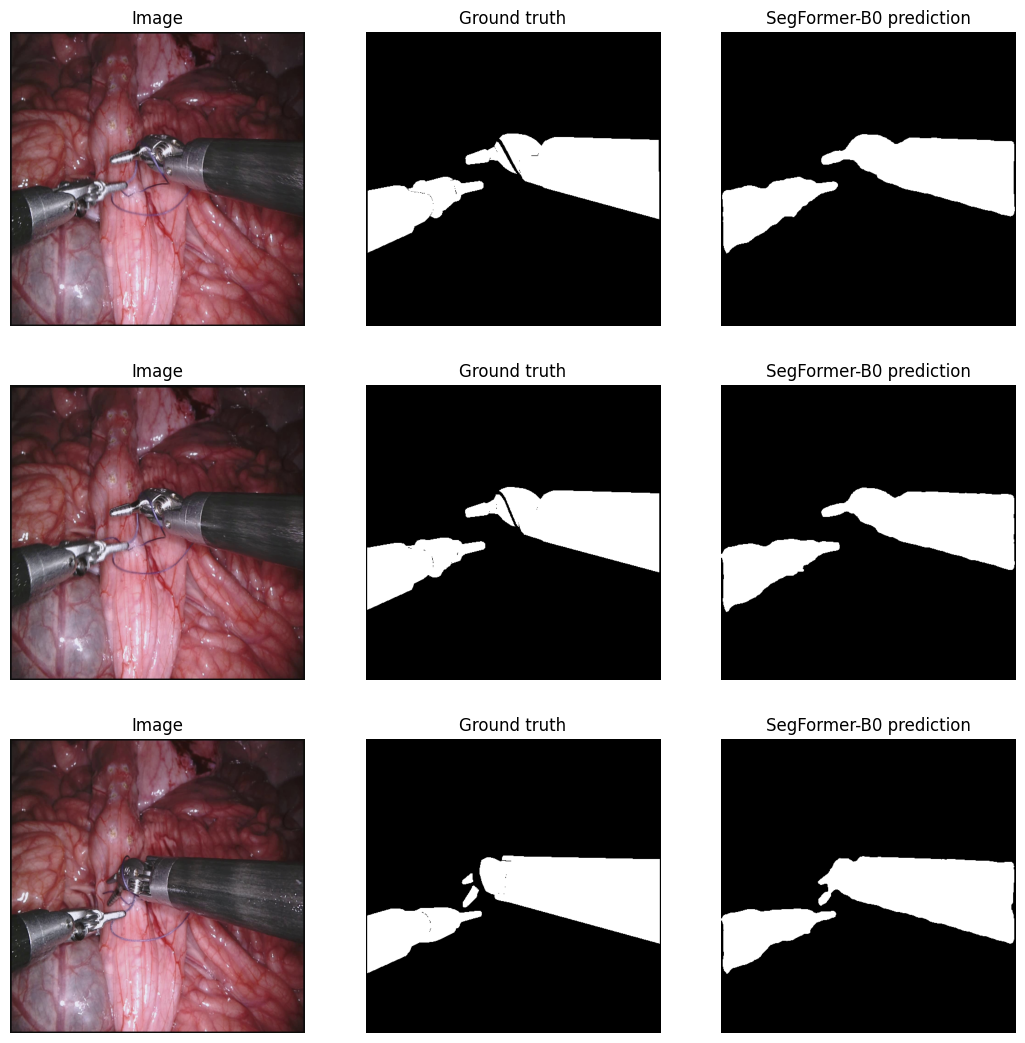

In [13]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return ((tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)


best_model = load_trained_model(best_model_name)
images, masks = next(iter(test_loader))
with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
    logits = best_model(images.to(DEVICE).contiguous(memory_format=torch.channels_last))
predictions = (torch.sigmoid(logits).cpu() >= 0.5)

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
for index in range(3):
    axes[index, 0].imshow(denormalize(images[index]))
    axes[index, 0].set_title("Image")
    axes[index, 1].imshow(masks[index, 0], cmap="gray")
    axes[index, 1].set_title("Ground truth")
    axes[index, 2].imshow(predictions[index, 0], cmap="gray")
    axes[index, 2].set_title(f"{best_model_name} prediction")
    for axis in axes[index]:
        axis.axis("off")
plt.show()

## 10. CholecT50 segmentation and simple tracking demo

CholecT50 does not contain segmentation masks in this release, so this is a qualitative cross-domain demo. The selected EndoVis model predicts instrument masks, and connected components are matched between frames by centroid distance.

In [14]:
@torch.inference_mode()
def predict_mask(model, pil_image):
    original_height, original_width = pil_image.height, pil_image.width
    resized = TF.resize(pil_image, IMAGE_SIZE, InterpolationMode.BILINEAR, antialias=True)
    tensor = TF.normalize(TF.to_tensor(resized), IMAGENET_MEAN, IMAGENET_STD)
    tensor = tensor.unsqueeze(0).to(DEVICE).contiguous(memory_format=torch.channels_last)
    with torch.autocast(device_type="cuda", dtype=torch.float16):
        probability = torch.sigmoid(model(tensor))[0, 0]
    probability = F.interpolate(
        probability[None, None],
        size=(original_height, original_width),
        mode="bilinear",
        align_corners=False,
    )[0, 0]
    return probability.cpu().numpy() >= 0.5


class CentroidTracker:
    def __init__(self, maximum_distance=100, maximum_missing=8):
        self.maximum_distance = maximum_distance
        self.maximum_missing = maximum_missing
        self.next_id = 1
        self.tracks = {}

    def update(self, detections):
        unmatched = set(range(len(detections)))
        for track_id in list(self.tracks):
            track = self.tracks[track_id]
            if detections:
                distances = [math.dist(track["centroid"], detection["centroid"]) for detection in detections]
                best = int(np.argmin(distances))
                if best in unmatched and distances[best] <= self.maximum_distance:
                    self.tracks[track_id] = {**detections[best], "missing": 0}
                    unmatched.remove(best)
                    continue
            track["missing"] += 1
            if track["missing"] > self.maximum_missing:
                del self.tracks[track_id]

        for index in unmatched:
            self.tracks[self.next_id] = {**detections[index], "missing": 0}
            self.next_id += 1
        return self.tracks


def mask_components(mask, minimum_area=200):
    count, _, stats, centroids = cv2.connectedComponentsWithStats(mask.astype(np.uint8), 8)
    detections = []
    for component in range(1, count):
        x, y, width, height, area = stats[component]
        if area >= minimum_area:
            detections.append({
                "centroid": tuple(centroids[component]),
                "box": (x, y, x + width, y + height),
            })
    return detections

In [15]:
video_name = "VID68"
frame_paths = sorted(
    path for path in (CHOLECT_ROOT / "videos" / video_name).glob("*.png")
    if re.fullmatch(r"\d{6}\.png", path.name)
)[:150]
assert frame_paths, f"No CholecT50 frames found in {video_name}"

tracker = CentroidTracker()
output_path = RESULT_DIR / f"{video_name}_{best_model_name}_tracking.mp4"
writer = None

try:
    for frame_path in frame_paths:
        pil_image = Image.open(frame_path).convert("RGB")
        frame = np.asarray(pil_image).copy()
        mask = predict_mask(best_model, pil_image)
        tracks = tracker.update(mask_components(mask))

        green = np.zeros_like(frame)
        green[..., 1] = 255
        frame[mask] = (0.55 * frame[mask] + 0.45 * green[mask]).astype(np.uint8)

        for track_id, track in tracks.items():
            if track["missing"]:
                continue
            x1, y1, x2, y2 = track["box"]
            cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 255, 0), 2)
            cv2.putText(frame, f"ID {track_id}", (x1, max(20, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

        if writer is None:
            height, width = frame.shape[:2]
            writer = cv2.VideoWriter(
                str(output_path), cv2.VideoWriter_fourcc(*"mp4v"), 10, (width, height)
            )
        writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
finally:
    if writer is not None:
        writer.release()

print("Saved tracking video:", output_path)

Saved tracking video: /content/drive/MyDrive/CV Project/results/VID68_SegFormer-B0_tracking.mp4


## Outputs

After the notebook finishes:

- Best checkpoints are stored in `/content/drive/MyDrive/CV Project/checkpoints`.
- The model comparison is printed in the test section.
- The CholecT50 tracking video is stored in `/content/drive/MyDrive/CV Project/results`.

The final model is selected by validation IoU while sequence 10 remains the independent test set.